In [1]:
# Install packages
!pip -q install geopandas pyogrio networkx scikit-learn


In [2]:
# Import tools
import json
import shutil
import zipfile

import ee
import geopandas as gpd
import google.auth
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from google.colab import auth, files
from itertools import combinations
from math import comb
from pathlib import Path
from scipy.linalg import qr
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial import Voronoi
from scipy.spatial.distance import cdist
from scipy.stats import beta as betadist
from scipy.stats import spearmanr
from shapely.geometry import Polygon, shape
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.pairwise import nan_euclidean_distances


In [3]:
# Set plot style
plt.rc("text",usetex=False)
plt.rc("font",family="serif")
plt.rc("mathtext",fontset="cm")
plt.rc("font",size=13)
plt.rc("axes",labelsize=14)
plt.rc("xtick",labelsize=11)
plt.rc("ytick",labelsize=11)
plt.rc("legend",fontsize=11)
plt.rc("xtick",top=False,direction="out")
plt.rc("ytick",right=False,direction="out")
plt.rc("xtick.major",size=4.5,width=0.9)
plt.rc("ytick.major",size=4.5,width=0.9)
plt.rc("lines",linewidth=1.8,markersize=4.5,markeredgewidth=0.8)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
colors = {"blue":"#0072B2","orange":"#D55E00","green":"#009E73","purple":"#CC79A7","gray":"#7F7F7F"}


In [4]:
# Set protocol
PROJECT = "taps-505803"
REGION = "California"
PRIMARY = "stratified"
SEED = 7
COUNT = 100
KINDS = ["uniform","population","stratified","clustered"]
START = 2021
END = 2025
MONTHS = [6,7,8,9,10]
NEIGHBORS = 10
BANDS = 3
BUDGET = 10
MAXBUDGET = 30
TRIALS = 200
K = 30
CLOCK = np.array([0,.25,.5])
HORIZON = 1.
BSCALE = .01
TOL = 1e-6
POOL = 5000
RAWPOOL = 7000
CLUSTERS = 8
CLUSTERSCALE = 35
PRUNE = 1e-6
ACCESS = pd.Timestamp.now(tz="UTC").date().isoformat()
OUT = Path("prospective_results")
WINDOWS = [f"{year}-{month:02d}" for year in range(START,END+1) for month in MONTHS]

AOD = "MODIS/061/MCD19A2_GRANULES"
ERA = "ECMWF/ERA5/HOURLY"
POP = "JRC/GHSL/P2023A/GHS_POP/2020"
ELEV = "USGS/3DEP/10m_collection"
LAND = "ESA/WorldCover/v200"
STATES = "TIGER/2018/States"

protocol = pd.DataFrame([{
    "region":REGION,
    "primary":PRIMARY,
    "candidates":COUNT,
    "candidate_types":"|".join(KINDS),
    "start_year":START,
    "end_year":END,
    "season_months":"|".join(map(str,MONTHS)),
    "windows":len(WINDOWS),
    "neighbors":NEIGHBORS,
    "regions":BANDS,
    "budget":BUDGET,
    "max_budget":MAXBUDGET,
    "K":K,
    "clock":"|".join(map(str,CLOCK)),
    "horizon":HORIZON,
    "beta_scale":BSCALE,
    "random_trials":TRIALS,
    "seed":SEED,
    "access_date_utc":ACCESS
}])

display(protocol.T)


,0
region,California
primary,stratified
candidates,100
candidate_types,uniform|population|stratified|clustered
start_year,2021
end_year,2025
season_months,6|7|8|9|10
windows,25
neighbors,10
regions,3


In [5]:
# Connect Earth Engine
auth.authenticate_user()
credentials,_ = google.auth.default()
ee.Initialize(credentials=credentials,project=PROJECT)
print(ee.String("Earth Engine connected").getInfo())


Earth Engine connected


In [6]:
# Load study sources
states = ee.FeatureCollection(STATES)
california = ee.Feature(states.filter(ee.Filter.eq("STUSPS","CA")).first())
worldcover = ee.ImageCollection(LAND).first().select("Map")
land = worldcover.neq(80).rename("land").clip(california.geometry())

popraw = ee.Image(POP).select("population_count")
population = popraw.updateMask(popraw.gte(0)).rename("population")
elevation = ee.ImageCollection(ELEV).filterBounds(california.geometry()).mosaic().select("elevation")

start = f"{START}-01-01"
end = f"{END+1}-01-01"
season = ee.Filter.calendarRange(min(MONTHS),max(MONTHS),"month")

aod = (
    ee.ImageCollection(AOD)
    .filterBounds(california.geometry())
    .filterDate(start,end)
    .filter(season)
    .select(["Optical_Depth_047","Optical_Depth_055","AOD_QA"])
)

era = (
    ee.ImageCollection(ERA)
    .filterBounds(california.geometry())
    .filterDate(start,end)
    .filter(season)
    .select([
        "temperature_2m",
        "dewpoint_temperature_2m",
        "total_precipitation",
        "surface_pressure",
        "u_component_of_wind_10m",
        "v_component_of_wind_10m"
    ])
)

eraproj = era.first().select("temperature_2m").projection()
erascale = eraproj.nominalScale().getInfo()

geometry = shape(california.geometry().getInfo())
ca = gpd.GeoDataFrame({"region":[REGION]},geometry=[geometry],crs=4326).to_crs(3310)


In [7]:
# Audit study sources
expected = sum(pd.Period(f"{year}-{month:02d}",freq="M").days_in_month*24 for year in range(START,END+1) for month in MONTHS)
aodcount = aod.size().getInfo()
eracount = era.size().getInfo()

sources = pd.DataFrame([
    ["MAIAC AOD",AOD,"Satellite aerosol",aodcount,aodcount>0,"https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MCD19A2_GRANULES"],
    ["ERA5 hourly",ERA,"Meteorology",eracount,eracount==expected,"https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_HOURLY"],
    ["GHSL population",POP,"Population target",1,"population" in population.bandNames().getInfo(),"https://developers.google.com/earth-engine/datasets/catalog/JRC_GHSL_P2023A_GHS_POP"],
    ["3DEP elevation",ELEV,"Static terrain",1,"elevation" in elevation.bandNames().getInfo(),"https://developers.google.com/earth-engine/datasets/catalog/USGS_3DEP_10m_collection"],
    ["WorldCover",LAND,"Land mask",1,"Map" in worldcover.bandNames().getInfo(),"https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v200"],
    ["TIGER states",STATES,"California boundary",1,california.get("STUSPS").getInfo()=="CA","https://developers.google.com/earth-engine/datasets/catalog/TIGER_2018_States"]
],columns=["source","asset","role","records","passed","url"])

sources["access_date_utc"] = ACCESS
display(sources[["source","records","passed"]])
print("Ground-monitor PM2.5 loaded:",False)


,source,records,passed
0,MAIAC AOD,66283,True
1,ERA5 hourly,18360,True
2,GHSL population,1,True
3,3DEP elevation,1,True
4,WorldCover,1,True
5,TIGER states,1,True


Ground-monitor PM2.5 loaded: False


In [8]:
# Build candidate pool
static = land.addBands(population.unmask(0)).addBands(elevation.unmask(-9999))
draws = ee.FeatureCollection.randomPoints(region=california.geometry(),points=RAWPOOL,seed=SEED,maxError=1)

poolfc = (
    static.sampleRegions(collection=draws,scale=100,geometries=True,tileScale=4)
    .filter(ee.Filter.eq("land",1))
    .filter(ee.Filter.gt("elevation",-9000))
    .limit(POOL)
)

print("Raw points:",RAWPOOL)
print("Valid land points:",poolfc.size().getInfo())


Raw points: 7000
Valid land points: 5000


In [9]:
# Load candidate pool
poolrows = []

for feature in poolfc.getInfo()["features"]:
    longitude,latitude = feature["geometry"]["coordinates"]
    values = feature["properties"]
    poolrows.append({
        "longitude":longitude,
        "latitude":latitude,
        "population":values["population"],
        "elevation":values["elevation"]
    })

pool = gpd.GeoDataFrame(
    poolrows,
    geometry=gpd.points_from_xy([row["longitude"] for row in poolrows],[row["latitude"] for row in poolrows]),
    crs=4326
).to_crs(3310)

pool = pool.drop_duplicates(subset=["longitude","latitude"]).reset_index(drop=True)
pool["pool"] = np.arange(len(pool))

poolaudit = pd.DataFrame({
    "metric":["candidates","unique","positive_population","minimum_elevation","maximum_elevation"],
    "value":[len(pool),pool.geometry.nunique(),pool["population"].gt(0).sum(),pool["elevation"].min(),pool["elevation"].max()]
})

display(poolaudit)


,metric,value
0,candidates,4999.000000
1,unique,4999.000000
2,positive_population,387.000000
3,minimum_elevation,-82.667679
4,maximum_elevation,3811.906250


In [10]:
# Define candidate designs
def make(name,index):
    frame = pool.iloc[index].copy()
    frame["candidate"] = [f"{name}_{i+1:03d}" for i in range(len(frame))]
    frame["distribution"] = name
    return frame[["candidate","distribution","pool","longitude","latitude","population","elevation","geometry"]].reset_index(drop=True)

def spread(frame,count,rng):
    xy = np.column_stack([frame.geometry.x,frame.geometry.y])
    first = int(rng.integers(len(frame)))
    selected = [first]
    distance = np.sum((xy-xy[first])**2,axis=1)
    distance[first] = -1

    for _ in range(1,count):
        index = int(np.argmax(distance))
        selected.append(index)
        new = np.sum((xy-xy[index])**2,axis=1)
        distance = np.minimum(distance,new)
        distance[selected] = -1

    return np.asarray(selected)

def cluster(frame,count,rng):
    xy = np.column_stack([frame.geometry.x,frame.geometry.y])
    centers = rng.choice(len(frame),size=CLUSTERS,replace=False)
    distance = cdist(xy,xy[centers]).min(axis=1)/1000
    weight = np.exp(-.5*(distance/CLUSTERSCALE)**2)
    return rng.choice(len(frame),size=count,replace=False,p=weight/weight.sum())

def candstats(name,frame):
    xy = np.column_stack([frame.geometry.x,frame.geometry.y])
    distance = cdist(xy,xy)/1000
    np.fill_diagonal(distance,np.nan)
    nearest = np.nanmin(distance,axis=1)

    return {
        "distribution":name,
        "candidates":len(frame),
        "unique":frame.geometry.nunique(),
        "minimum_spacing_km":nearest.min(),
        "median_nearest_km":np.median(nearest),
        "median_population":frame["population"].median(),
        "mean_population":frame["population"].mean(),
        "median_elevation":frame["elevation"].median()
    }


In [11]:
# Generate candidate designs
rng0 = np.random.default_rng(SEED)
rng1 = np.random.default_rng(SEED+1)
rng2 = np.random.default_rng(SEED+2)
rng3 = np.random.default_rng(SEED+3)

uniform = rng0.choice(len(pool),size=COUNT,replace=False)
popweights = pool["population"].clip(lower=0).to_numpy(float)
populationids = rng1.choice(len(pool),size=COUNT,replace=False,p=popweights/popweights.sum())
stratified = spread(pool,COUNT,rng2)
clustered = cluster(pool,COUNT,rng3)

sets = {
    "uniform":make("uniform",uniform),
    "population":make("population",populationids),
    "stratified":make("stratified",stratified),
    "clustered":make("clustered",clustered)
}

candidateaudit = pd.DataFrame([candstats(name,frame) for name,frame in sets.items()])
display(candidateaudit.round(3))


,distribution,candidates,unique,minimum_spacing_km,median_nearest_km,median_population,mean_population,median_elevation
0,uniform,100,100,1.814,32.852,0.000,3.526,658.776
1,population,100,100,0.980,9.698,28.532,39.950,84.766
2,stratified,100,100,57.218,64.245,0.000,2.353,633.581
3,clustered,100,100,2.149,15.223,0.000,1.789,1092.800


In [12]:
# Prepare sampling sites
allsites = gpd.GeoDataFrame(pd.concat(list(sets.values()),ignore_index=True),crs=3310).to_crs(4326)
features = []

for row in allsites.itertuples():
    features.append(ee.Feature(
        ee.Geometry.Point([row.geometry.x,row.geometry.y]),
        {"candidate":row.candidate,"distribution":row.distribution}
    ))

sitefc = ee.FeatureCollection(features)
static = allsites[["candidate","distribution","population","elevation"]].copy()

print("Candidate rows:",len(allsites))
print("Earth Engine features:",sitefc.size().getInfo())


Candidate rows: 400
Earth Engine features: 400


In [13]:
# Define monthly sampling
def maskaod(image):
    qa = image.select("AOD_QA")
    landqa = qa.rightShift(3).bitwiseAnd(3).eq(0)
    quality = qa.rightShift(8).bitwiseAnd(15).eq(0)
    values = image.select(["Optical_Depth_047","Optical_Depth_055"]).multiply(.001)
    return values.updateMask(landqa.And(quality)).updateMask(values.gte(0))

def monthaod(year,month):
    begin = ee.Date.fromYMD(year,month,1)
    finish = begin.advance(1,"month")
    return (
        aod.filterDate(begin,finish)
        .map(maskaod)
        .median()
        .rename(["aod047","aod055"])
    )

def monthmet(year,month):
    begin = ee.Date.fromYMD(year,month,1)
    finish = begin.advance(1,"month")
    subset = era.filterDate(begin,finish)
    means = subset.select([
        "temperature_2m",
        "dewpoint_temperature_2m",
        "surface_pressure",
        "u_component_of_wind_10m",
        "v_component_of_wind_10m"
    ]).mean()

    return (
        means.select("temperature_2m").subtract(273.15).rename("temp")
        .addBands(means.select("dewpoint_temperature_2m").subtract(273.15).rename("dew"))
        .addBands(means.select("surface_pressure").divide(1000).rename("pressure"))
        .addBands(means.select("u_component_of_wind_10m").rename("windu"))
        .addBands(means.select("v_component_of_wind_10m").rename("windv"))
        .addBands(subset.select("total_precipitation").sum().multiply(1000).rename("rain"))
        .setDefaultProjection(eraproj)
    )

def readfc(collection):
    return pd.DataFrame([feature["properties"] for feature in collection.getInfo()["features"]])

def samplemonth(year,month):
    aframe = readfc(monthaod(year,month).reduceRegions(
        collection=sitefc,reducer=ee.Reducer.mean(),scale=1000,crs="EPSG:3310",tileScale=4
    ))
    mframe = readfc(monthmet(year,month).reduceRegions(
        collection=sitefc,reducer=ee.Reducer.mean(),scale=erascale,crs=eraproj,tileScale=4
    ))

    for column in ["candidate","distribution","aod047","aod055"]:
        if column not in aframe:
            aframe[column] = np.nan

    for column in ["candidate","temp","dew","pressure","windu","windv","rain"]:
        if column not in mframe:
            mframe[column] = np.nan

    frame = (
        aframe[["candidate","distribution","aod047","aod055"]]
        .merge(mframe[["candidate","temp","dew","pressure","windu","windv","rain"]],on="candidate",how="left")
        .merge(static,on=["candidate","distribution"],how="left")
    )

    frame["year"] = year
    frame["month"] = month
    frame["window"] = f"{year}-{month:02d}"
    return frame


In [14]:
# Extract environmental signatures
parts = []

for index,window in enumerate(WINDOWS,1):
    year = int(window[:4])
    month = int(window[5:7])
    print(f"{index:02d}/{len(WINDOWS)}",window)
    parts.append(samplemonth(year,month))

data = (
    pd.concat(parts,ignore_index=True)
    .sort_values(["distribution","candidate","year","month"])
    .reset_index(drop=True)
)

metcols = ["temp","dew","pressure","windu","windv","rain"]

dataaudit = pd.DataFrame({
    "metric":["rows","expected_rows","candidates","windows","missing_aod_fraction","missing_meteorology_fraction"],
    "value":[
        len(data),
        len(allsites)*len(WINDOWS),
        data["candidate"].nunique(),
        data["window"].nunique(),
        data["aod055"].isna().mean(),
        data[metcols].isna().mean().mean()
    ]
})

display(dataaudit)


01/25 2021-06
02/25 2021-07
03/25 2021-08
04/25 2021-09
05/25 2021-10
06/25 2022-06
07/25 2022-07
08/25 2022-08
09/25 2022-09
10/25 2022-10
11/25 2023-06
12/25 2023-07
13/25 2023-08
14/25 2023-09
15/25 2023-10
16/25 2024-06
17/25 2024-07
18/25 2024-08
19/25 2024-09
20/25 2024-10
21/25 2025-06
22/25 2025-07
23/25 2025-08
24/25 2025-09
25/25 2025-10


,metric,value
0,rows,10000.0000
1,expected_rows,10000.0000
2,candidates,400.0000
3,windows,25.0000
4,missing_aod_fraction,0.0055
5,missing_meteorology_fraction,0.0000


In [15]:
# Define environmental signatures
def standard(values):
    mean = np.nanmean(values,axis=0)
    scale = np.nanstd(values,axis=0)
    scale[~np.isfinite(scale)|(scale<1e-12)] = 1
    return (values-mean)/scale

def signature(name,windows):
    subset = data[data["distribution"].eq(name)&data["window"].isin(windows)].copy()
    ids = sorted(subset["candidate"].unique())

    aodblock = (
        subset.pivot(index="candidate",columns="window",values="aod055")
        .reindex(index=ids,columns=windows)
        .to_numpy(float)
    )
    aodblock = standard(aodblock)/np.sqrt(aodblock.shape[1])

    metparts = []
    for column in metcols:
        values = (
            subset.pivot(index="candidate",columns="window",values=column)
            .reindex(index=ids,columns=windows)
            .to_numpy(float)
        )
        metparts.append(values)

    metblock = standard(np.column_stack(metparts))
    metblock = metblock/np.sqrt(metblock.shape[1])

    staticblock = (
        subset.groupby("candidate")[["elevation"]]
        .first()
        .reindex(ids)
        .to_numpy(float)
    )
    staticblock = standard(staticblock)

    return ids,np.column_stack([aodblock,metblock,staticblock])


In [16]:
# Prepare graph distances
locations = {}
distances = {}

for name in KINDS:
    ids,_ = signature(name,WINDOWS)
    frame = sets[name].set_index("candidate").loc[ids].to_crs(3310)
    xy = np.column_stack([frame.geometry.x,frame.geometry.y])
    locations[name] = frame
    distances[name] = cdist(xy,xy)/1000

print("Full signature dimensions:",signature(PRIMARY,WINDOWS)[1].shape[1])


Full signature dimensions: 176


In [17]:
# Define prospective graphs
def edges(distance,k):
    order = np.argsort(distance,axis=1)[:,1:k+1]
    selected = set()

    for i in range(len(distance)):
        for j in order[i]:
            selected.add(tuple(sorted((i,int(j)))))

    complete = nx.Graph()
    complete.add_nodes_from(range(len(distance)))

    for i in range(len(distance)):
        for j in range(i+1,len(distance)):
            complete.add_edge(i,j,weight=float(distance[i,j]))

    tree = nx.minimum_spanning_tree(complete,weight="weight")
    bridges = {tuple(sorted(edge)) for edge in tree.edges()}
    selected.update(bridges)
    return sorted(selected),bridges

def makegraph(name,windows):
    ids,matrix = signature(name,windows)
    geo = distances[name]
    env = nan_euclidean_distances(matrix)
    selected,bridges = edges(geo,NEIGHBORS)

    geovalues = np.array([geo[i,j] for i,j in selected])
    envvalues = np.array([env[i,j] for i,j in selected])
    siggeo = max(np.median(geovalues),1e-12)
    sigenv = max(np.median(envvalues),1e-12)

    graph = nx.Graph()
    graph.add_nodes_from(ids)

    for i,j in selected:
        weight = np.exp(-(geo[i,j]/siggeo)**2)*np.exp(-(env[i,j]/sigenv)**2)
        graph.add_edge(
            ids[i],ids[j],
            weight=float(weight),
            geographic_km=float(geo[i,j]),
            environmental_distance=float(env[i,j]),
            bridge=tuple(sorted((i,j))) in bridges
        )

    weights = np.array([value["weight"] for _,_,value in graph.edges(data=True)])
    robust = graph.copy()
    robust.remove_edges_from([
        (u,v) for u,v,value in robust.edges(data=True)
        if value["weight"]<weights.max()*PRUNE
    ])

    W = nx.to_numpy_array(graph,nodelist=ids,weight="weight")
    values = np.linalg.eigvalsh(np.diag(W.sum(axis=1))-W)

    return {
        "ids":ids,
        "graph":graph,
        "W":W,
        "sigma_geo":siggeo,
        "sigma_env":sigenv,
        "lambda1":max(float(values[1]),0.),
        "components":nx.number_connected_components(graph),
        "robust":nx.number_connected_components(robust),
        "bridge":max(geo[i,j] for i,j in bridges),
        "minimum":weights.min()
    }


In [18]:
# Build reference graphs
refs = {name:makegraph(name,WINDOWS) for name in KINDS}

graphaudit = pd.DataFrame([
    {
        "distribution":name,
        "k":NEIGHBORS,
        "edges":value["graph"].number_of_edges(),
        "components":value["components"],
        "robust_components":value["robust"],
        "lambda1":value["lambda1"],
        "sigma_geo_km":value["sigma_geo"],
        "sigma_environment":value["sigma_env"],
        "maximum_mst_km":value["bridge"],
        "minimum_weight":value["minimum"]
    }
    for name,value in refs.items()
])

display(graphaudit.round(6))


,distribution,k,edges,components,robust_components,lambda1,sigma_geo_km,sigma_environment,maximum_mst_km,minimum_weight
0,uniform,10,599,1,1,0.014237,93.138135,1.613348,92.662633,0.000002
1,population,10,645,1,4,0.000000,40.279422,1.479347,155.509480,0.000000
2,stratified,10,576,1,1,0.023276,115.538014,1.539807,102.598427,0.000005
3,clustered,10,625,1,3,0.000000,44.723640,1.249849,468.856257,0.000000


In [19]:
# Define Voronoi cells
def finite(voronoi,radius=None):
    regions = []
    vertices = voronoi.vertices.tolist()
    center = voronoi.points.mean(axis=0)

    if radius is None:
        radius = np.ptp(voronoi.points,axis=0).max()*4

    ridges = {}
    for (p1,p2),(v1,v2) in zip(voronoi.ridge_points,voronoi.ridge_vertices):
        ridges.setdefault(p1,[]).append((p2,v1,v2))
        ridges.setdefault(p2,[]).append((p1,v1,v2))

    for point,regionid in enumerate(voronoi.point_region):
        region = voronoi.regions[regionid]

        if all(vertex>=0 for vertex in region):
            regions.append(region)
            continue

        new = [vertex for vertex in region if vertex>=0]

        for neighbor,v1,v2 in ridges[point]:
            if v1>=0 and v2>=0:
                continue

            vertex = v1 if v1>=0 else v2
            tangent = voronoi.points[neighbor]-voronoi.points[point]
            tangent = tangent/np.linalg.norm(tangent)
            normal = np.array([-tangent[1],tangent[0]])
            midpoint = (voronoi.points[point]+voronoi.points[neighbor])/2
            direction = np.sign(np.dot(midpoint-center,normal))*normal
            far = voronoi.vertices[vertex]+direction*radius
            vertices.append(far.tolist())
            new.append(len(vertices)-1)

        polygon = np.asarray([vertices[vertex] for vertex in new])
        middle = polygon.mean(axis=0)
        angle = np.arctan2(polygon[:,1]-middle[1],polygon[:,0]-middle[0])
        regions.append(np.asarray(new)[np.argsort(angle)].tolist())

    return regions,np.asarray(vertices)


In [20]:
# Build population target
primary = refs[PRIMARY]
ids = primary["ids"]
sites = locations[PRIMARY].loc[ids].copy()
xy = np.column_stack([sites.geometry.x,sites.geometry.y])

vor = Voronoi(xy)
vorregions,vertices = finite(vor)
cageom = ca.geometry.iloc[0]
cellrows = []

for candidate,region in zip(ids,vorregions):
    polygon = Polygon(vertices[region]).intersection(cageom)
    cellrows.append({"candidate":candidate,"geometry":polygon})

cells = gpd.GeoDataFrame(cellrows,crs=3310).to_crs(4326)
cellfeatures = [ee.Feature(ee.Geometry(row.geometry.__geo_interface__),{"candidate":row.candidate}) for row in cells.itertuples()]
cellfc = ee.FeatureCollection(cellfeatures)

popproj = population.projection()
popscale = popproj.nominalScale().getInfo()

statepop = float(population.reduceRegion(
    reducer=ee.Reducer.sum(),geometry=california.geometry(),scale=popscale,crs=popproj,maxPixels=1e9,tileScale=4
).getInfo()["population"])

result = population.reduceRegions(
    collection=cellfc,reducer=ee.Reducer.sum(),scale=popscale,crs=popproj,tileScale=4
).getInfo()["features"]

target = pd.DataFrame([
    {"candidate":feature["properties"]["candidate"],"population":feature["properties"].get("sum",0)}
    for feature in result
]).set_index("candidate").reindex(ids)

target["population"] = pd.to_numeric(target["population"],errors="coerce").fillna(0)
target["weight"] = target["population"]/target["population"].sum()

targetaudit = pd.DataFrame({
    "metric":["represented_population","state_population","represented_fraction","positive_candidates","maximum_weight","effective_support","weight_sum"],
    "value":[
        target["population"].sum(),
        statepop,
        target["population"].sum()/statepop,
        target["weight"].gt(0).sum(),
        target["weight"].max(),
        1/np.sum(target["weight"]**2),
        target["weight"].sum()
    ]
})

display(targetaudit)


,metric,value
0,represented_population,4.042468e+07
1,state_population,4.042492e+07
2,represented_fraction,9.999941e-01
3,positive_candidates,1.000000e+02
4,maximum_weight,2.397841e-01
5,effective_support,1.066240e+01
6,weight_sum,1.000000e+00


In [21]:
# Define target model
def makemodel(item,k):
    W = item["W"]
    values,vectors = np.linalg.eigh(np.diag(W.sum(axis=1))-W)
    basis = vectors[:,:k]
    lambdas = values[:k]
    scale = lambdas[-1]
    clock = CLOCK/scale
    horizon = HORIZON/scale
    weights = target["weight"].reindex(item["ids"]).to_numpy(float)
    decay = np.exp(-np.outer(clock,lambdas))
    blocks = basis[:,None,:]*decay[None,:,:]
    info = np.einsum("vtk,vtl->vkl",blocks,blocks)
    g = np.exp(-horizon*lambdas)*(basis.T@weights)
    beta = BSCALE*np.trace(info.sum(axis=0))/k

    return {
        "ids":item["ids"],
        "K":k,
        "beta":beta,
        "blocks":blocks,
        "info":info,
        "g":g,
        "weights":weights,
        "basis":basis,
        "values":values,
        "vectors":vectors,
        "W":W,
        "distance":distances[PRIMARY],
        "clock":clock,
        "horizon":horizon
    }

base = makemodel(primary,K)
energy = np.sort(base["g"]**2)[::-1]
effdim = int(np.searchsorted(np.cumsum(energy)/energy.sum(),.95)+1)

modelaudit = pd.DataFrame({
    "metric":["K","effective_target_dimension","beta","lambda1","lambdaK","target_norm"],
    "value":[K,effdim,base["beta"],base["values"][1],base["values"][K-1],np.linalg.norm(base["g"])]
})

display(modelaudit)


,metric,value
0,K,30.000000
1,effective_target_dimension,12.000000
2,beta,0.023908
3,lambda1,0.023276
4,lambdaK,1.107133
5,target_norm,0.196828


In [22]:
# Define sensor designs
def metrics(model,selected):
    if len(selected)==0:
        return {
            "span_error":1.,"mismatch":1.,"amplification":0.,"risk":1.,
            "rank":0,"sigma_min":0.,"full_state_risk":1.
        }

    B = model["blocks"][selected].reshape(-1,model["K"])
    g = model["g"]
    beta = model["beta"]
    norm = np.linalg.norm(g)

    exact = np.linalg.lstsq(B.T,g,rcond=None)[0]
    span = np.linalg.norm(B.T@exact-g)/norm
    M = beta*np.eye(model["K"])+B.T@B
    h = np.linalg.solve(M,g)
    coefficients = B@h
    mismatch = np.linalg.norm(B.T@coefficients-g)/norm
    amplification = np.sqrt(beta)*np.linalg.norm(coefficients)/norm
    risk = np.sqrt(mismatch**2+amplification**2)
    rank = int(np.linalg.matrix_rank(B))
    singular = np.linalg.svd(B,compute_uv=False)
    sigma = float(singular[-1]) if rank==model["K"] else 0.

    return {
        "span_error":span,
        "mismatch":mismatch,
        "amplification":amplification,
        "risk":risk,
        "rank":rank,
        "sigma_min":sigma,
        "full_state_risk":np.sqrt(beta/(sigma**2+beta))
    }

def taps(model,budget):
    M = model["beta"]*np.eye(model["K"])
    selected = []
    available = np.ones(len(model["ids"]),dtype=bool)
    norm = model["g"]@model["g"]

    for _ in range(budget):
        best = -1
        score = np.inf

        for candidate in np.flatnonzero(available):
            value = model["beta"]*(model["g"]@np.linalg.solve(M+model["info"][candidate],model["g"]))/norm
            if value<score-1e-14:
                best = int(candidate)
                score = value

        selected.append(best)
        available[best] = False
        M = M+model["info"][best]

    return selected

def raw(model,budget):
    M = model["beta"]*np.eye(model["K"])
    selected = []
    available = np.ones(len(model["ids"]),dtype=bool)

    for _ in range(budget):
        h = np.linalg.solve(M,model["g"])
        response = np.einsum("vtk,k->vt",model["blocks"],h)
        score = np.sum(response**2,axis=1)
        score[~available] = -np.inf
        best = int(np.argmax(score))
        selected.append(best)
        available[best] = False
        M = M+model["info"][best]

    return selected

def designs(model,budget):
    targetorder = np.argsort(-model["weights"],kind="stable")[:budget].tolist()

    geographic = [int(np.argmin(model["distance"].max(axis=1)))]
    while len(geographic)<budget:
        nearest = model["distance"][:,geographic].min(axis=1)
        nearest[geographic] = -np.inf
        geographic.append(int(np.argmax(nearest)))

    M = model["beta"]*np.eye(model["K"])
    doptimal = []
    available = np.ones(len(model["ids"]),dtype=bool)

    for _ in range(budget):
        best = -1
        score = -np.inf

        for candidate in np.flatnonzero(available):
            sign,value = np.linalg.slogdet(M+model["info"][candidate])
            if sign>0 and value>score+1e-12:
                best = int(candidate)
                score = value

        doptimal.append(best)
        available[best] = False
        M = M+model["info"][best]

    _,_,pivots = qr(model["basis"].T,pivoting=True,mode="economic")

    return {
        "TAPS":taps(model,budget),
        "Raw response":raw(model,budget),
        "Target weight":targetorder,
        "Geographic coverage":geographic,
        "D-optimal":doptimal,
        "QR pivoting":[int(value) for value in pivots[:budget]]
    }


In [23]:
# Run TAPS prefix
tapsprefix = taps(base,MAXBUDGET)
curverows = []

for budget in range(MAXBUDGET+1):
    curverows.append({"budget":budget,**metrics(base,tapsprefix[:budget])})

curve = pd.DataFrame(curverows)
exact = curve[curve["span_error"].lt(TOL)]
fullrank = curve[curve["rank"].ge(K)]
primaryexact = int(exact["budget"].iloc[0]) if len(exact) else None
primaryrank = int(fullrank["budget"].iloc[0]) if len(fullrank) else None

tapsaudit = pd.DataFrame({
    "metric":["first_exact_budget","first_full_rank_budget","exact_before_full_rank","risk_at_10","span_at_10","rank_at_10","full_state_risk_at_10"],
    "value":[
        primaryexact,
        primaryrank,
        primaryexact is not None and (primaryrank is None or primaryexact<primaryrank),
        curve.loc[curve["budget"].eq(10),"risk"].iloc[0],
        curve.loc[curve["budget"].eq(10),"span_error"].iloc[0],
        curve.loc[curve["budget"].eq(10),"rank"].iloc[0],
        curve.loc[curve["budget"].eq(10),"full_state_risk"].iloc[0]
    ]
})

display(tapsaudit)


,metric,value
0,first_exact_budget,10
1,first_full_rank_budget,10
2,exact_before_full_rank,False
3,risk_at_10,0.170584
4,span_at_10,0.0
5,rank_at_10,30
6,full_state_risk_at_10,1.0


In [24]:
# Evaluate deterministic budgets
orders = designs(base,MAXBUDGET)
budgetrows = []

for method,order in orders.items():
    for budget in range(1,MAXBUDGET+1):
        budgetrows.append({"method":method,"budget":budget,**metrics(base,order[:budget])})

budgets = pd.DataFrame(budgetrows)

display(
    budgets[budgets["budget"].eq(10)][
        ["method","span_error","mismatch","amplification","risk","rank","full_state_risk"]
    ].sort_values("risk").round(6)
)


,method,span_error,mismatch,amplification,risk,rank,full_state_risk
9,TAPS,0.0,0.099767,0.138367,0.170584,30,1.0
39,Raw response,0.0,0.125814,0.156105,0.200495,30,1.0
69,Target weight,0.0,0.210601,0.130772,0.247900,30,1.0
99,Geographic coverage,0.0,0.769444,0.219017,0.800008,30,1.0
159,QR pivoting,0.0,0.918227,0.239808,0.949025,30,1.0
129,D-optimal,0.0,0.918517,0.240311,0.949433,30,1.0


In [25]:
# Evaluate random budgets
def q10(values):
    return values.quantile(.10)

def q90(values):
    return values.quantile(.90)

def above90(values):
    return values.ge(.90).mean()

def within10(values):
    return values.le(1.10).mean()

rng = np.random.default_rng(SEED)
randomorders = [rng.permutation(len(ids)).tolist() for _ in range(TRIALS)]
randomrows = []

for trial,order in enumerate(randomorders,1):
    for budget in range(1,MAXBUDGET+1):
        value = metrics(base,order[:budget])
        randomrows.append({
            "trial":trial,
            "budget":budget,
            "risk":value["risk"],
            "span_error":value["span_error"],
            "rank":value["rank"]
        })

random = pd.DataFrame(randomrows)
randomsummary = (
    random.groupby("budget")
    .agg(
        median_risk=("risk","median"),
        p10_risk=("risk",q10),
        p90_risk=("risk",q90),
        median_span=("span_error","median"),
        median_rank=("rank","median")
    )
    .reset_index()
)

unique = len({tuple(sorted(order[:10])) for order in randomorders})
print("Random trials:",TRIALS)
print("Unique ten-sensor sets:",unique)


Random trials: 200
Unique ten-sensor sets: 200


In [26]:
# Summarize sensor efficiency
reference = budgets[budgets["method"].eq("TAPS")&budgets["budget"].eq(BUDGET)]["risk"].iloc[0]
effrows = []

for method in orders:
    frame = budgets[budgets["method"].eq(method)].sort_values("budget")
    reached = frame[frame["risk"]<=reference]
    required = int(reached["budget"].iloc[0]) if len(reached) else None
    effrows.append({
        "method":method,
        "sensors_to_match_taps_10":required,
        "risk_at_10":frame.loc[frame["budget"].eq(10),"risk"].iloc[0]
    })

reached = randomsummary[randomsummary["median_risk"]<=reference]
effrows.append({
    "method":"Random median",
    "sensors_to_match_taps_10":int(reached["budget"].iloc[0]) if len(reached) else None,
    "risk_at_10":randomsummary.loc[randomsummary["budget"].eq(10),"median_risk"].iloc[0]
})

efficiency = pd.DataFrame(effrows)

random10 = random[random["budget"].eq(10)]["risk"].to_numpy(float)
random30 = random[random["budget"].eq(30)]["risk"].to_numpy(float)
beaten = int(np.sum(random10>reference))
low = 0. if beaten==0 else betadist.ppf(.025,beaten,TRIALS-beaten+1)
high = 1. if beaten==TRIALS else betadist.ppf(.975,beaten+1,TRIALS-beaten)

randomaudit = pd.DataFrame({
    "metric":["taps_risk_10","random_median_10","best_random_10","random_sets_beaten","percent_random_beaten","percentile_low","percentile_high","random_30_worse_than_taps_10"],
    "value":[reference,np.median(random10),np.min(random10),beaten,100*beaten/TRIALS,100*low,100*high,int(np.sum(random30>reference))]
})

display(efficiency)
display(randomaudit)


,method,sensors_to_match_taps_10,risk_at_10
0,TAPS,10.0,0.170584
1,Raw response,16.0,0.200495
2,Target weight,16.0,0.247900
3,Geographic coverage,NaN,0.800008
4,D-optimal,29.0,0.949433
5,QR pivoting,29.0,0.949025
6,Random median,NaN,0.848240


,metric,value
0,taps_risk_10,0.170584
1,random_median_10,0.848240
2,best_random_10,0.247508
3,random_sets_beaten,200.000000
4,percent_random_beaten,100.000000
5,percentile_low,98.172466
6,percentile_high,100.000000
7,random_30_worse_than_taps_10,183.000000


In [27]:
# Audit marginal gains
M = base["beta"]*np.eye(base["K"])
available = np.ones(len(ids),dtype=bool)
gainrows = []
norm = base["g"]@base["g"]

for step in range(BUDGET):
    h = np.linalg.solve(M,base["g"])
    rawscore = np.full(len(ids),-np.inf)
    gain = np.full(len(ids),-np.inf)
    retention = np.full(len(ids),np.nan)

    for candidate in np.flatnonzero(available):
        block = base["blocks"][candidate]
        q = block@h
        A = base["beta"]*np.dot(q,q)/norm
        G = block@np.linalg.solve(M,block.T)
        eta = q@np.linalg.solve(np.eye(len(q))+G,q)/np.dot(q,q) if np.dot(q,q)>0 else 0.
        rawscore[candidate] = A
        gain[candidate] = A*eta
        retention[candidate] = eta

    chosen = int(np.argmax(gain))
    leader = int(np.argmax(rawscore))
    before = base["beta"]*(base["g"]@np.linalg.solve(M,base["g"]))/norm
    after = base["beta"]*(base["g"]@np.linalg.solve(M+base["info"][chosen],base["g"]))/norm

    gainrows.append({
        "step":step+1,
        "taps_candidate":ids[chosen],
        "raw_candidate":ids[leader],
        "same_candidate":chosen==leader,
        "taps_raw_response":rawscore[chosen],
        "raw_leader_response":rawscore[leader],
        "taps_retention":retention[chosen],
        "raw_leader_retention":retention[leader],
        "taps_gain":gain[chosen],
        "raw_leader_gain":gain[leader],
        "gain_error":abs((before-after)-gain[chosen])
    })

    available[chosen] = False
    M = M+base["info"][chosen]

gains = pd.DataFrame(gainrows)
skipped = gains[~gains["same_candidate"]]

display(gains.round(6))
print("Raw-response leader skipped:",len(skipped),"of",BUDGET)
print("Higher retention whenever skipped:",(skipped["taps_retention"]>skipped["raw_leader_retention"]).all())
print("Maximum gain error:",gains["gain_error"].max())


,step,taps_candidate,raw_candidate,same_candidate,taps_raw_response,raw_leader_response,taps_retention,raw_leader_retention,taps_gain,raw_leader_gain,gain_error
0,1,stratified_049,stratified_022,False,15.766256,45.669004,0.041936,0.013102,0.661167,0.598372,0.0
1,2,stratified_087,stratified_022,False,1.406324,5.899217,0.089690,0.019027,0.126133,0.112243,0.0
2,3,stratified_022,stratified_022,True,5.176932,5.176932,0.019201,0.019201,0.099403,0.099403,0.0
3,4,stratified_009,stratified_047,False,0.598132,0.632008,0.058499,0.017535,0.034990,0.011082,0.0
4,5,stratified_008,stratified_047,False,0.095121,0.534116,0.171006,0.012617,0.016266,0.006739,0.0
5,6,stratified_034,stratified_047,False,0.023074,0.510074,0.369638,0.012166,0.008529,0.006206,0.0
6,7,stratified_021,stratified_047,False,0.190584,0.491967,0.044311,0.012432,0.008445,0.006116,0.0
7,8,stratified_084,stratified_036,False,0.103526,0.485177,0.067989,0.010847,0.007039,0.005263,0.0
8,9,stratified_036,stratified_036,True,0.480150,0.480150,0.010853,0.010853,0.005211,0.005211,0.0
9,10,stratified_092,stratified_047,False,0.008718,0.163518,0.426503,0.012575,0.003718,0.002056,0.0


Raw-response leader skipped: 8 of 10
Higher retention whenever skipped: True
Maximum gain error: 2.220446049250313e-16


In [28]:
# Define connected regions
def tree(W):
    mask = W>0
    cost = np.zeros_like(W)
    cost[mask] = np.maximum(-np.log(np.clip(W[mask],1e-12,1)),1e-9)
    result = minimum_spanning_tree(csr_matrix(cost))
    result = (result+result.T).tocoo()
    adj = [[] for _ in range(len(W))]
    edges = []

    for u,v in zip(result.row,result.col):
        u = int(u)
        v = int(v)

        if u>=v:
            continue

        adj[u].append(v)
        adj[v].append(u)
        edges.append((u,v,float(W[u,v])))

    return adj,edges

def component(start,nodes,blocked,adj):
    bu,bv = blocked
    seen = {start}
    stack = [start]

    while stack:
        u = stack.pop()

        for v in adj[u]:
            if v not in nodes:
                continue
            if (u==bu and v==bv) or (u==bv and v==bu):
                continue
            if v not in seen:
                seen.add(v)
                stack.append(v)

    return seen

def cut(nodes,parts,mass,minimum,penalty,adj,edges):
    leftparts = parts//2
    rightparts = parts-leftparts
    targetfraction = leftparts/parts
    total = mass[list(nodes)].sum()
    internal = [edge for edge in edges if edge[0] in nodes and edge[1] in nodes]
    maximum = max(edge[2] for edge in internal)
    best = None
    bestkey = None

    for required in [minimum,1]:
        for u,v,strength in internal:
            first = component(u,nodes,(u,v),adj)
            second = nodes-first

            for left,right in [(first,second),(second,first)]:
                if len(left)<leftparts*required or len(right)<rightparts*required:
                    continue

                fraction = mass[list(left)].sum()/total
                balance = abs(fraction-targetfraction)
                size = abs(len(left)/len(nodes)-targetfraction)
                edgepenalty = penalty*strength/maximum
                key = (balance+.01*size+edgepenalty,balance,edgepenalty,min(u,v),max(u,v))

                if bestkey is None or key<bestkey:
                    bestkey = key
                    best = (left,right)

        if best is not None:
            break

    return best

def partition(nodes,parts,mass,minimum,penalty,adj,edges):
    if parts==1:
        return [sorted(nodes)]

    leftparts = parts//2
    rightparts = parts-leftparts
    left,right = cut(nodes,parts,mass,minimum,penalty,adj,edges)

    return (
        partition(left,leftparts,mass,minimum,penalty,adj,edges)
        +partition(right,rightparts,mass,minimum,penalty,adj,edges)
    )

def response(model):
    h = model["g"]/model["beta"]
    values = np.einsum("vtk,k->vt",model["blocks"],h)
    return model["beta"]*np.sum(values**2,axis=1)/(model["g"]@model["g"])

def labels(model):
    rawvalues = response(model)
    targetmass = rawvalues/rawvalues.sum()
    mass = .5*targetmass+.5/len(rawvalues)
    adj,edges = tree(model["W"])
    parts = partition(set(range(len(rawvalues))),BANDS,mass,5,.05,adj,edges)
    means = np.array([rawvalues[part].mean() for part in parts])
    order = np.argsort(-means)
    result = np.zeros(len(rawvalues),dtype=int)

    for band,index in enumerate(order,1):
        result[parts[index]] = band

    return result,mass,rawvalues

def treeids(W):
    _,edges = tree(W)
    return {tuple(sorted((u,v))) for u,v,_ in edges}


In [29]:
# Build reference regions
regionlabels,regionmass,rawvalues = labels(base)
regionrows = []

for band in range(1,BANDS+1):
    index = np.where(regionlabels==band)[0]
    nodes = [ids[i] for i in index]

    regionrows.append({
        "region":band,
        "candidates":len(index),
        "mass_share":regionmass[index].sum(),
        "population_share":base["weights"][index].sum(),
        "raw_response_share":rawvalues[index].sum()/rawvalues.sum(),
        "mean_raw_response":rawvalues[index].mean(),
        "connected":nx.is_connected(primary["graph"].subgraph(nodes))
    })

regionsaudit = pd.DataFrame(regionrows)
display(regionsaudit.round(4))


,region,candidates,mass_share,population_share,raw_response_share,mean_raw_response,connected
0,1,6,0.4013,0.5167,0.7426,13.6362,True
1,2,61,0.4076,0.4452,0.2053,0.3708,True
2,3,33,0.1911,0.0381,0.0521,0.1740,True


In [30]:
# Define window models
def windowmodel(windows,k=K):
    item = makegraph(PRIMARY,windows)
    model = makemodel(item,k)
    region,_,rawvalues = labels(model)
    return item,model,region,rawvalues


In [31]:
# Diagnose chronological stability
fulltree = treeids(base["W"])
mask = np.triu(base["W"]>0,k=1)
chronorows = []

for count in range(1,len(WINDOWS)+1):
    item,model,region,rawcurrent = windowmodel(WINDOWS[:count])
    overlap = np.linalg.norm(model["basis"].T@base["basis"],ord="fro")**2/K
    currenttree = treeids(item["W"])

    chronorows.append({
        "windows":count,
        "last_window":WINDOWS[count-1],
        "weight_correlation":np.corrcoef(item["W"][mask],base["W"][mask])[0,1],
        "relative_weight_error":np.linalg.norm(item["W"]-base["W"])/np.linalg.norm(base["W"]),
        "spectral_overlap":overlap,
        "raw_response_correlation":spearmanr(rawcurrent,rawvalues).statistic,
        "mst_edge_overlap":len(currenttree&fulltree)/len(fulltree),
        "node_agreement":np.mean(region==regionlabels),
        "adjusted_rand":adjusted_rand_score(regionlabels,region)
    })

chronology = pd.DataFrame(chronorows)
display(chronology.round(3))


,windows,last_window,weight_correlation,relative_weight_error,spectral_overlap,raw_response_correlation,mst_edge_overlap,node_agreement,adjusted_rand
0,1,2021-06,0.885,0.365,0.830,0.931,0.788,0.11,0.533
1,2,2021-07,0.897,0.325,0.831,0.951,0.778,0.61,0.198
2,3,2021-08,0.905,0.309,0.803,0.952,0.798,0.61,0.198
3,4,2021-09,0.906,0.306,0.811,0.953,0.808,0.61,0.198
4,5,2021-10,0.927,0.267,0.850,0.958,0.859,0.29,0.229
5,6,2022-06,0.937,0.248,0.853,0.944,0.848,0.08,0.572
6,7,2022-07,0.944,0.232,0.857,0.957,0.879,0.18,0.465
7,8,2022-08,0.947,0.225,0.851,0.935,0.879,0.18,0.465
8,9,2022-09,0.957,0.202,0.875,0.940,0.848,0.16,0.466
9,10,2022-10,0.963,0.186,0.883,0.981,0.869,0.17,0.456


In [32]:
# Test window subsets
rng = np.random.default_rng(SEED+101)
subsetrows = []

for size in [1,2,3,5,10,15,20,24]:
    repeats = min(25,comb(len(WINDOWS),size))
    choices = set()

    while len(choices)<repeats:
        choices.add(tuple(sorted(rng.choice(len(WINDOWS),size=size,replace=False))))

    for repeat,index in enumerate(sorted(choices),1):
        windows = [WINDOWS[i] for i in index]
        _,_,region,_ = windowmodel(windows)
        subsetrows.append({
            "windows":size,
            "repeat":repeat,
            "node_agreement":np.mean(region==regionlabels),
            "adjusted_rand":adjusted_rand_score(regionlabels,region)
        })

subsetrows.append({"windows":25,"repeat":1,"node_agreement":1.,"adjusted_rand":1.})
subsets = pd.DataFrame(subsetrows)

subsetsummary = (
    subsets.groupby("windows")
    .agg(
        runs=("adjusted_rand","size"),
        median_agreement=("node_agreement","median"),
        p10_agreement=("node_agreement",q10),
        median_ari=("adjusted_rand","median"),
        p10_ari=("adjusted_rand",q10),
        maximum_ari=("adjusted_rand","max"),
        fraction_ari_90=("adjusted_rand",above90)
    )
    .reset_index()
)

display(subsetsummary.round(3))


,windows,runs,median_agreement,p10_agreement,median_ari,p10_ari,maximum_ari,fraction_ari_90
0,1,25,0.29,0.086,0.433,0.308,0.970,0.04
1,2,25,0.67,0.104,0.429,0.196,0.819,0.00
2,3,25,0.57,0.076,0.464,0.222,0.836,0.00
3,5,25,0.70,0.064,0.563,0.212,0.956,0.16
4,10,25,0.68,0.050,0.547,0.304,1.000,0.32
5,15,25,0.84,0.150,0.870,0.199,0.962,0.36
6,20,25,0.68,0.150,0.512,0.181,1.000,0.20
7,24,25,0.68,0.030,0.906,0.199,1.000,0.68
8,25,1,1.00,1.000,1.000,1.000,1.000,1.00


In [33]:
# Test complete seasons
seasonrows = []
years = list(range(START,END+1))

for count in range(1,len(years)+1):
    for chosen in combinations(years,count):
        windows = [window for window in WINDOWS if int(window[:4]) in chosen]
        _,_,region,_ = windowmodel(windows)

        seasonrows.append({
            "seasons":count,
            "years":"-".join(map(str,chosen)),
            "windows":len(windows),
            "node_agreement":np.mean(region==regionlabels),
            "adjusted_rand":adjusted_rand_score(regionlabels,region)
        })

seasons = pd.DataFrame(seasonrows)

seasonsummary = (
    seasons.groupby("seasons")
    .agg(
        runs=("adjusted_rand","size"),
        median_agreement=("node_agreement","median"),
        minimum_agreement=("node_agreement","min"),
        median_ari=("adjusted_rand","median"),
        minimum_ari=("adjusted_rand","min"),
        maximum_ari=("adjusted_rand","max"),
        fraction_ari_90=("adjusted_rand",above90)
    )
    .reset_index()
)

display(seasonsummary.round(3))


,seasons,runs,median_agreement,minimum_agreement,median_ari,minimum_ari,maximum_ari,fraction_ari_90
0,1,5,0.290,0.10,0.507,0.229,0.894,0.0
1,2,10,0.165,0.03,0.547,0.199,0.962,0.2
2,3,10,0.165,0.04,0.546,0.199,1.000,0.2
3,4,5,0.150,0.03,0.565,0.199,0.962,0.4
4,5,1,1.000,1.00,1.000,1.000,1.000,1.0


In [34]:
# Test sensor stability
rng = np.random.default_rng(SEED+303)
referencetaps = set(orders["TAPS"][:BUDGET])
sensorrows = []

for size in [5,10,15,20,24]:
    choices = set()

    while len(choices)<25:
        choices.add(tuple(sorted(rng.choice(len(WINDOWS),size=size,replace=False))))

    for repeat,index in enumerate(sorted(choices),1):
        windows = [WINDOWS[i] for i in index]
        _,model,_,_ = windowmodel(windows)
        selected = taps(model,BUDGET)
        overlap = len(set(selected)&referencetaps)
        value = metrics(base,selected)

        sensorrows.append({
            "windows":size,
            "repeat":repeat,
            "overlap":overlap,
            "jaccard":overlap/(2*BUDGET-overlap),
            "full_stack_risk":value["risk"],
            "risk_ratio":value["risk"]/reference
        })

sensorrows.append({
    "windows":25,"repeat":1,"overlap":BUDGET,"jaccard":1.,"full_stack_risk":reference,"risk_ratio":1.
})

sensors = pd.DataFrame(sensorrows)

sensorsummary = (
    sensors.groupby("windows")
    .agg(
        runs=("overlap","size"),
        median_overlap=("overlap","median"),
        p10_overlap=("overlap",q10),
        median_jaccard=("jaccard","median"),
        median_full_risk=("full_stack_risk","median"),
        p90_full_risk=("full_stack_risk",q90),
        median_risk_ratio=("risk_ratio","median"),
        fraction_within_10pct=("risk_ratio",within10)
    )
    .reset_index()
)

display(sensorsummary.round(3))


,windows,runs,median_overlap,p10_overlap,median_jaccard,median_full_risk,p90_full_risk,median_risk_ratio,fraction_within_10pct
0,5,25,5.0,4.0,0.333,0.182,0.193,1.067,0.68
1,10,25,5.0,4.0,0.333,0.176,0.187,1.032,0.92
2,15,25,6.0,5.0,0.429,0.174,0.183,1.020,0.96
3,20,25,7.0,4.4,0.538,0.172,0.177,1.011,1.00
4,24,25,10.0,5.4,1.000,0.171,0.176,1.000,1.00
5,25,1,10.0,10.0,1.000,0.171,0.171,1.000,1.00


In [35]:
# Test retained dimensions
dimensionrows = []

for tested in [20,30,40,50]:
    model = makemodel(primary,tested)
    prefix = taps(model,MAXBUDGET)
    rows = []

    for budget in range(1,MAXBUDGET+1):
        rows.append({"budget":budget,**metrics(model,prefix[:budget])})

    frame = pd.DataFrame(rows)
    exactset = frame[frame["span_error"].lt(TOL)]
    rankset = frame[frame["rank"].ge(tested)]
    exactk = int(exactset["budget"].iloc[0]) if len(exactset) else None
    rankk = int(rankset["budget"].iloc[0]) if len(rankset) else None
    energy = np.sort(model["g"]**2)[::-1]
    effective = int(np.searchsorted(np.cumsum(energy)/energy.sum(),.95)+1)
    ten = frame[frame["budget"].eq(10)].iloc[0]

    dimensionrows.append({
        "K":tested,
        "effective_target_dimension":effective,
        "first_exact_budget":exactk,
        "first_full_rank_budget":rankk,
        "exact_before_full_rank":exactk is not None and (rankk is None or exactk<rankk),
        "risk_at_10":ten["risk"],
        "span_at_10":ten["span_error"],
        "rank_at_10":int(ten["rank"]),
        "full_state_risk_at_10":ten["full_state_risk"]
    })

dimensions = pd.DataFrame(dimensionrows)
display(dimensions.round(6))


,K,effective_target_dimension,first_exact_budget,first_full_rank_budget,exact_before_full_rank,risk_at_10,span_at_10,rank_at_10,full_state_risk_at_10
0,20,9,7,7,False,0.173480,0.000000,20,1.0
1,30,12,10,10,False,0.170584,0.000000,30,1.0
2,40,14,14,14,False,0.165926,0.006627,30,1.0
3,50,15,17,17,False,0.170128,0.036286,30,1.0


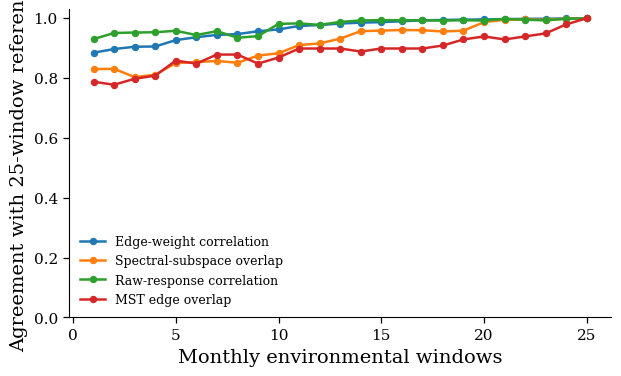

In [36]:
# Plot graph stability
fig,ax = plt.subplots(figsize=(7,4))

for column,label in [
    ("weight_correlation","Edge-weight correlation"),
    ("spectral_overlap","Spectral-subspace overlap"),
    ("raw_response_correlation","Raw-response correlation"),
    ("mst_edge_overlap","MST edge overlap")
]:
    ax.plot(chronology["windows"],chronology[column],marker="o",label=label)

ax.set(xlabel="Monthly environmental windows",ylabel="Agreement with 25-window reference",ylim=(0,1.03))
ax.legend(frameon=False,fontsize=9)
fig.savefig("stability.png",dpi=220,bbox_inches="tight")
plt.show()


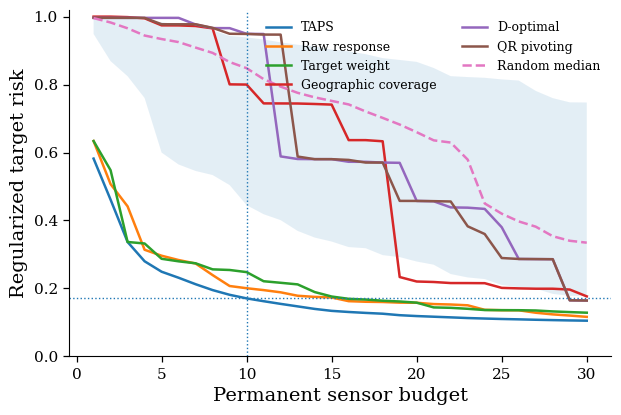

In [37]:
# Plot sensor efficiency
fig,ax = plt.subplots(figsize=(7,4.5))

for method in orders:
    frame = budgets[budgets["method"].eq(method)]
    ax.plot(frame["budget"],frame["risk"],label=method)

ax.plot(randomsummary["budget"],randomsummary["median_risk"],linestyle="--",label="Random median")
ax.fill_between(randomsummary["budget"],randomsummary["p10_risk"],randomsummary["p90_risk"],alpha=.12)
ax.axhline(reference,linestyle=":",linewidth=1)
ax.axvline(BUDGET,linestyle=":",linewidth=1)
ax.set(xlabel="Permanent sensor budget",ylabel="Regularized target risk",ylim=(0,1.02))
ax.legend(frameon=False,fontsize=9,ncol=2)
fig.savefig("efficiency.png",dpi=220,bbox_inches="tight")
plt.show()


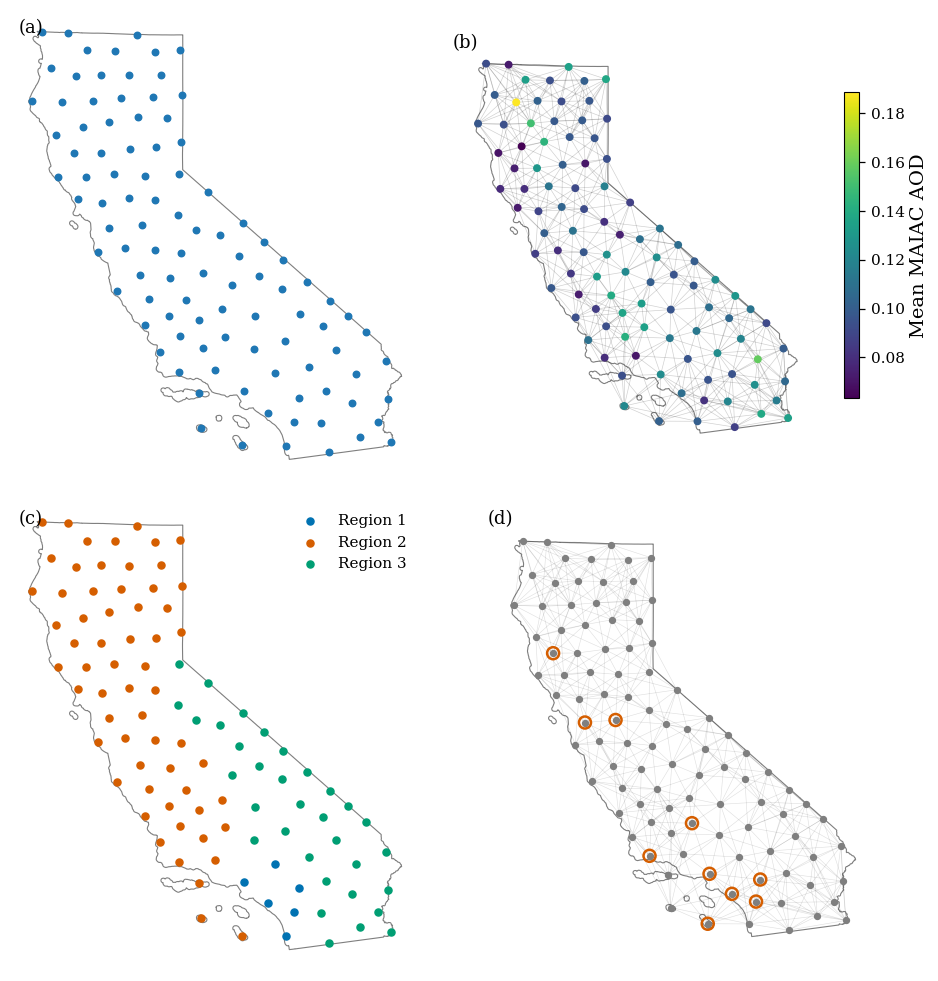

In [38]:
# Plot prospective pipeline
taps10 = np.asarray(ids)[orders["TAPS"][:BUDGET]]
positions = {
    candidate:(sites.loc[candidate].geometry.x,sites.loc[candidate].geometry.y)
    for candidate in ids
}
meanaod = (
    data[data["distribution"].eq(PRIMARY)]
    .groupby("candidate")["aod055"]
    .mean()
    .reindex(ids)
)

fig,axes = plt.subplots(2,2,figsize=(10,10))

for ax in axes.ravel():
    ca.plot(ax=ax,facecolor="none",edgecolor=colors["gray"],linewidth=.8)
    ax.axis("off")

sites.plot(ax=axes[0,0],markersize=22)
axes[0,0].text(.02,.98,"(a)",transform=axes[0,0].transAxes,ha="left",va="top")

nx.draw_networkx_edges(primary["graph"],positions,ax=axes[0,1],width=.5,alpha=.18)
points = axes[0,1].scatter(sites.geometry.x,sites.geometry.y,c=meanaod.to_numpy(),s=22)
fig.colorbar(points,ax=axes[0,1],shrink=.65,label="Mean MAIAC AOD")
axes[0,1].text(.02,.98,"(b)",transform=axes[0,1].transAxes,ha="left",va="top")

regioncolors = [colors["blue"],colors["orange"],colors["green"]]

for band in range(1,BANDS+1):
    index = np.where(regionlabels==band)[0]
    sites.iloc[index].plot(
        ax=axes[1,0],
        markersize=26,
        color=regioncolors[band-1],
        label=f"Region {band}"
    )

axes[1,0].legend(frameon=False)
axes[1,0].text(.02,.98,"(c)",transform=axes[1,0].transAxes,ha="left",va="top")

nx.draw_networkx_edges(primary["graph"],positions,ax=axes[1,1],width=.45,alpha=.12)
sites.plot(ax=axes[1,1],markersize=18,color=colors["gray"])
sites.loc[taps10].plot(
    ax=axes[1,1],
    markersize=75,
    facecolor="none",
    edgecolor=colors["orange"],
    linewidth=1.8
)
axes[1,1].text(.02,.98,"(d)",transform=axes[1,1].transAxes,ha="left",va="top")

fig.tight_layout()
fig.savefig("pipeline.png",dpi=220,bbox_inches="tight")
plt.show()


In [39]:
# Summarize prospective results
summary = pd.DataFrame([
    ["candidate_universe",PRIMARY],
    ["hypothetical_candidates",len(ids)],
    ["environmental_windows",len(WINDOWS)],
    ["primary_retained_dimension",K],
    ["effective_target_dimension",effdim],
    ["taps_risk_10",reference],
    ["raw_risk_10",budgets[budgets["method"].eq("Raw response")&budgets["budget"].eq(10)]["risk"].iloc[0]],
    ["target_risk_10",budgets[budgets["method"].eq("Target weight")&budgets["budget"].eq(10)]["risk"].iloc[0]],
    ["qr_risk_10",budgets[budgets["method"].eq("QR pivoting")&budgets["budget"].eq(10)]["risk"].iloc[0]],
    ["first_exact_budget",primaryexact],
    ["first_full_rank_budget",primaryrank],
    ["random_sets_beaten",beaten],
    ["random_percentile",100*beaten/TRIALS],
    ["random_percentile_low",100*low],
    ["random_percentile_high",100*high],
    ["random_30_worse_than_taps_10",int(np.sum(random30>reference))],
    ["raw_leaders_skipped",len(skipped)],
    ["higher_retention_when_skipped",(skipped["taps_retention"]>skipped["raw_leader_retention"]).all()],
    ["ten_window_median_risk_ratio",sensorsummary.loc[sensorsummary["windows"].eq(10),"median_risk_ratio"].iloc[0]],
    ["twenty_window_fraction_within_10pct",sensorsummary.loc[sensorsummary["windows"].eq(20),"fraction_within_10pct"].iloc[0]],
    ["reference_region_sizes","-".join(regionsaudit["candidates"].astype(str))],
    ["aod_missing_fraction",data["aod055"].isna().mean()]
],columns=["result","value"])

display(summary)


,result,value
0,candidate_universe,stratified
1,hypothetical_candidates,100
2,environmental_windows,25
3,primary_retained_dimension,30
4,effective_target_dimension,12
5,taps_risk_10,0.170584
6,raw_risk_10,0.200495
7,target_risk_10,0.2479
8,qr_risk_10,0.949025
9,first_exact_budget,10


In [40]:
# Export prospective results
OUT.mkdir(exist_ok=True)

candidateparts = []

for frame in sets.values():
    export = frame.to_crs(4326).copy()
    export["longitude"] = export.geometry.x
    export["latitude"] = export.geometry.y
    candidateparts.append(export[
        ["candidate","distribution","longitude","latitude","population","elevation"]
    ])

candidates = pd.concat(candidateparts,ignore_index=True)

tables = {
    "protocol.csv":protocol,
    "sources.csv":sources,
    "candidates.csv":candidates,
    "signatures.csv":data,
    "graphs.csv":graphaudit,
    "target.csv":target.reset_index(),
    "regions.csv":regionsaudit,
    "chronology.csv":chronology,
    "subsets.csv":subsets,
    "seasons.csv":seasons,
    "curve.csv":curve,
    "budgets.csv":budgets,
    "random.csv":random,
    "efficiency.csv":efficiency,
    "gains.csv":gains,
    "sensors.csv":sensors,
    "dimensions.csv":dimensions,
    "summary.csv":summary
}

for name,frame in tables.items():
    frame.to_csv(OUT/name,index=False)

for name in ["pipeline.png","efficiency.png","stability.png"]:
    shutil.copy(name,OUT/name)

np.savez_compressed(
    OUT/"model.npz",
    ids=np.asarray(ids),
    adjacency=base["W"],
    values=base["values"],
    vectors=base["vectors"],
    basis=base["basis"],
    target=base["weights"],
    g=base["g"],
    beta=np.asarray(base["beta"]),
    blocks=base["blocks"],
    taps=np.asarray(orders["TAPS"],dtype=int),
    labels=regionlabels,
    clock=base["clock"],
    horizon=np.asarray(base["horizon"])
)

print("CSV files:",len(list(OUT.glob("*.csv"))))
print("Model saved:",(OUT/"model.npz").exists())


CSV files: 18
Model saved: True


In [41]:
# Archive prospective results
manifest = {
    "notebook":"08-prospective.ipynb",
    "purpose":"Prospective TAPS design from exogenous remotely sensed and environmental information",
    "region":REGION,
    "primary_candidate_distribution":PRIMARY,
    "candidate_count":COUNT,
    "candidate_distributions":KINDS,
    "environmental_years":[START,END],
    "season_months":MONTHS,
    "environmental_windows":len(WINDOWS),
    "graph_neighbors":NEIGHBORS,
    "graph_connectivity":"symmetric geographic kNN plus geographic MST",
    "aerosol_source":AOD,
    "meteorology_source":ERA,
    "population_source":POP,
    "elevation_source":ELEV,
    "landcover_source":LAND,
    "ground_monitor_pm25_used":False,
    "retained_dimension":K,
    "observation_normalized":CLOCK.tolist(),
    "target_normalized_horizon":HORIZON,
    "beta_scale":BSCALE,
    "sensor_budget":BUDGET,
    "random_trials":TRIALS,
    "seed":SEED,
    "exact_tolerance":TOL,
    "access_date_utc":ACCESS,
    "taps_ten_sensor_risk":float(reference),
    "random_ten_sensor_sets_beaten":int(beaten),
    "raw_response_leaders_skipped":int(len(skipped)),
    "first_taps_exact_budget":primaryexact,
    "first_taps_full_rank_budget":primaryrank,
    "region_stability_note":"Environmental graph stabilizes substantially earlier than the discrete MST-based three-region partition; region stability is retained as a diagnostic rather than a positive convergence claim."
}

with open(OUT/"manifest.json","w") as file:
    json.dump(manifest,file,indent=2)

archive = Path("prospective.zip")

if archive.exists():
    archive.unlink()

with zipfile.ZipFile(archive,"w",compression=zipfile.ZIP_DEFLATED) as zipped:
    for path in sorted(OUT.iterdir()):
        zipped.write(path,arcname=path.name)

with zipfile.ZipFile(archive) as zipped:
    members = zipped.namelist()
    bad = zipped.testzip()

    for name in members:
        if name.endswith(".csv"):
            with zipped.open(name) as file:
                pd.read_csv(file)

archiveaudit = pd.DataFrame({
    "metric":["archive_members","csv_files","corrupt_member","manifest","model","pipeline","efficiency","stability"],
    "value":[
        len(members),
        sum(name.endswith(".csv") for name in members),
        bad,
        "manifest.json" in members,
        "model.npz" in members,
        "pipeline.png" in members,
        "efficiency.png" in members,
        "stability.png" in members
    ]
})

display(archiveaudit)
files.download(str(archive))


,metric,value
0,archive_members,23
1,csv_files,18
2,corrupt_member,None
3,manifest,True
4,model,True
5,pipeline,True
6,efficiency,True
7,stability,True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>